# Calibration Cox

**This notebook assesses calibration performance of the Cox model and recalibrates predictions using isotonic regression.**

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from scipy.stats import linregress
from sklearn.model_selection import StratifiedKFold
from joblib import Parallel, delayed
from sklearn.isotonic import IsotonicRegression
from sksurv.metrics import brier_score

from utils.calibration import calculate_calibration_curve, calibrate_survival_predictions

## Import Data

In [2]:
survival_predictions_df = pd.read_csv('../outputs/cox_survival_predictions.csv')

In [3]:
survival_predictions_df = survival_predictions_df[['PatientID', 'risk_score', 'psurv_180']]

In [4]:
survival_predictions_df.shape

(9030, 3)

In [5]:
dtype_map = pd.read_csv('../outputs/ioio_tki_features_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
ioio_tki_df = pd.read_csv('../outputs/ioio_tki_features_df.csv', dtype = dtype_map)

In [6]:
ioio_tki_df.shape

(1339, 174)

In [7]:
df = pd.merge(ioio_tki_df, survival_predictions_df, on = 'PatientID', how = 'left')

In [8]:
df.shape

(1339, 176)

In [9]:
df = df.query('adv_diagnosis_year <= 2021')

In [10]:
df.shape

(1135, 176)

## Raw Calibration Assessment

In [11]:
cal_df = calculate_calibration_curve(df, 'psurv_180', 180)

In [12]:
cal_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(-0.000999999999999847, 0.495]",0.294338,0.392573,114,0.297661,0.478360
1,"(0.495, 0.625]",0.568101,0.533555,113,0.433281,0.623858
2,"(0.625, 0.696]",0.664020,0.646129,114,0.547498,0.728578
3,"(0.696, 0.74]",0.717787,0.700511,113,0.597475,0.770304
4,"(0.74, 0.781]",0.761820,0.793094,114,0.699484,0.852976
5,"(0.781, 0.808]",0.793836,0.790150,113,0.696270,0.851598
6,"(0.808, 0.838]",0.822229,0.910289,113,0.822308,0.940191
7,"(0.838, 0.869]",0.853799,0.899663,114,0.821911,0.940555
8,"(0.869, 0.899]",0.883517,0.944758,113,0.881150,0.974801
9,"(0.899, 0.996]",0.920223,0.972890,114,0.918306,0.991175


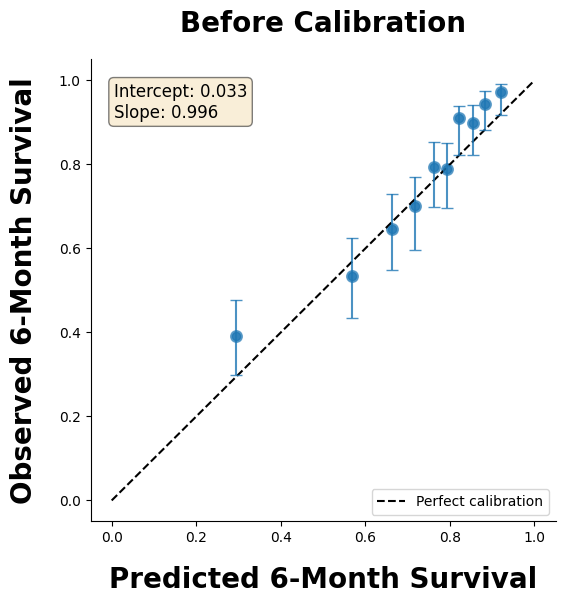

In [13]:
slope_orig, intercept_orig, _, _, _ = linregress(
    cal_df['predicted'], 
    cal_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_df['predicted'], cal_df['observed'], s = 70, alpha = 0.6)
plt.plot([0, 1], [0, 1], 'k--', label = 'Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_df['observed'] - cal_df['obs_lo'],
    cal_df['obs_hi'] - cal_df['observed']
])

plt.errorbar(
    cal_df['predicted'],
    cal_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,    
    capsize = 4,         
    alpha = 0.8
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_orig:.3f}\nSlope: {slope_orig:.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 12, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.title('Before Calibration',  weight = 'bold', size = 20, pad = 20)
plt.legend()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

## Isotonic Calibration Using Cross Validation 

In [14]:
# Prepare structured array for survival outcomes
y_dtype = [('event', bool), ('duration', float)]

y = np.array([tuple(x) for x in df[['event', 'duration']].values],
             dtype = y_dtype)

In [15]:
df, brier_scores = calibrate_survival_predictions(df, y, 'psurv_180', 180)


=== Fold 1/5 ===
Brier score at 180 days (calibrated): 0.1687

=== Fold 2/5 ===
Brier score at 180 days (calibrated): 0.1729

=== Fold 3/5 ===
Brier score at 180 days (calibrated): 0.1434

=== Fold 4/5 ===
Brier score at 180 days (calibrated): 0.1346

=== Fold 5/5 ===
Brier score at 180 days (calibrated): 0.1322

=== Summary ===
psurv_180_calibrated computed: 1135

=== Brier Scores at 180 days (calibrated) ===
Mean: 0.1503 ± 0.0171


In [16]:
df_final_calibrated = df[['PatientID', 'psurv_180_calibrated']]

In [17]:
df_final_calibrated.to_csv('../outputs/cox_6m_survival_predictions_calibrated.csv', index = False)

In [18]:
cal_iso_df = calculate_calibration_curve(df, 'psurv_180_calibrated', 180)

In [19]:
cal_iso_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(-0.001, 0.523]",0.351438,0.379243,120,0.287455,0.463905
1,"(0.523, 0.625]",0.585284,0.627546,140,0.539589,0.703356
2,"(0.625, 0.66]",0.648093,0.639637,99,0.531382,0.728336
3,"(0.66, 0.762]",0.728119,0.686705,110,0.585750,0.761178
4,"(0.762, 0.78]",0.773296,0.810721,116,0.712817,0.863479
5,"(0.78, 0.894]",0.830989,0.770409,103,0.665526,0.833842
6,"(0.894, 0.911]",0.907205,0.931323,147,0.869401,0.958520
7,"(0.911, 0.916]",0.915591,0.856374,74,0.741332,0.914968
8,"(0.916, 0.956]",0.946432,0.938652,118,0.875609,0.970276
9,"(0.956, 1.0]",0.985631,0.961718,108,0.901212,0.985458


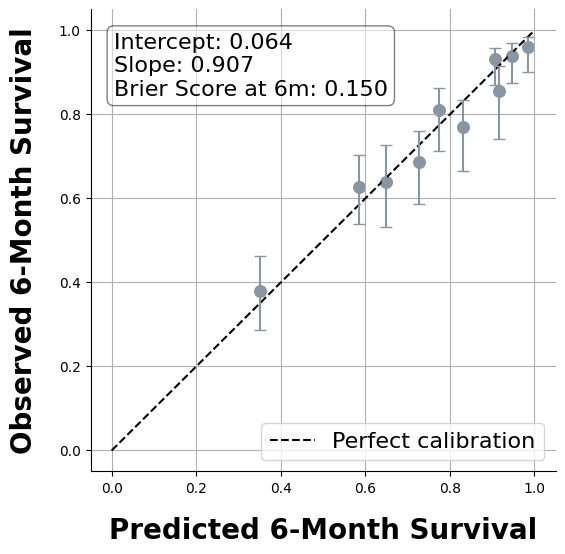

In [20]:
slope_iso, intercept_iso, _, _, _ = linregress(
    cal_iso_df['predicted'], 
    cal_iso_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_iso_df['predicted'], cal_iso_df['observed'], s = 70, color = '#8896A4')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_iso_df['observed'] - cal_iso_df['obs_lo'],
    cal_iso_df['obs_hi'] - cal_iso_df['observed']
])

plt.errorbar(
    cal_iso_df['predicted'],
    cal_iso_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,
    color = '#8896A4',
    capsize = 4
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_iso:.3f}\nSlope: {slope_iso:.3f}\nBrier Score at 6m: {np.mean(brier_scores):.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 16, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'white', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
#plt.title('After Isotonic Calibration',  weight = 'bold', size = 20, pad = 20)
plt.legend(fontsize=16)
plt.grid(True)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()